<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

import os
import sys

root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root not in sys.path:
    sys.path.insert(0, root)

In [3]:
mlflow.set_experiment(
    "assignment"
)

2026/05/16 00:25:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/16 00:25:30 INFO mlflow.store.db.utils: Updating database tables
2026/05/16 00:25:33 INFO mlflow.tracking.fluent: Experiment with name 'assignment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/paulorosado_visagio/github-classroom/ddefbcourses/atividade-03-mlp-paulorosadodev/notebooks/mlruns/1', creation_time=1778901933861, experiment_id='1', last_update_time=1778901933861, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [4]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from src.utils import set_seed, normalize_images

def load_data(seed):
    set_seed(seed)
    mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
    X = normalize_images(mnist['data'].astype('float32'))
    y = mnist['target'].astype('int64')
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = load_data(seed=42)

Sim, é necessário normalizar. Nas imagens, as cores dos pixels variam de 0 (preto) a 255 (branco). Normalizar significa dividir todos esses valores por 255, para que fiquem espremidos em uma escala de 0 a 1.

Fazemos isso porque as redes neurais não lidam bem com números grandes. Se usarmos o valor 255, as multiplicações dentro da rede geram resultados gigantes. Isso faz com que os neurônios 'batam no teto' de suas funções matemáticas e saturem, parando de aprender.

Com os números pequenos (de 0 a 1), a matemática flui de forma suave. A rede consegue ajustar seus pesos com passos curtos e precisos, deixando o treinamento muito mais rápido, estável e eficiente.

# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [5]:
from sklearn.neural_network import MLPClassifier
from src.experiment import measure_training_time

def train_mlp(X_train, y_train, activation, hidden_layers, learning_rate, seed, max_iter=100, batch_size=64):

    def _train():
        clf = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation=activation,
            learning_rate_init=learning_rate,
            random_state=seed,
            max_iter=max_iter,
            batch_size=batch_size,
            tol=1e-4,
            verbose=False,           
            early_stopping=True
        )
        clf.fit(X_train, y_train)
        return clf

    clf, training_time = measure_training_time(_train)
    return clf, training_time

# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [6]:
from src.metrics import classification_metrics

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = classification_metrics(y_test, y_pred)
    return metrics

# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [7]:
from src.experiment import start_run, log_params, log_metrics

def run_experiment(X_train, y_train, X_test, y_test, activation, hidden_layers, learning_rate, seed, max_iter=100, batch_size=64, run_name=None):

    with start_run(run_name=run_name):
        
        params = {
            "activation": activation,
            "hidden_layers": str(hidden_layers),  
            "learning_rate": learning_rate,
            "max_iter": max_iter,
            "batch_size": batch_size
        }
        log_params(params)
        
        model, training_time = train_mlp(
            X_train, y_train, 
            activation=activation, 
            hidden_layers=hidden_layers, 
            learning_rate=learning_rate, 
            seed=seed
        )
        
        metrics = evaluate(model, X_test, y_test)
        metrics["training_time"] = training_time
        
        log_metrics(metrics)
        
        return model, metrics

# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:


Executando experimento: q5_activation_logistic
[logistic] Acurácia: 0.8873 | Precisão: 0.8880 | Recall: 0.8873 | F1 Score: 0.8875 | Tempo: 150.21s


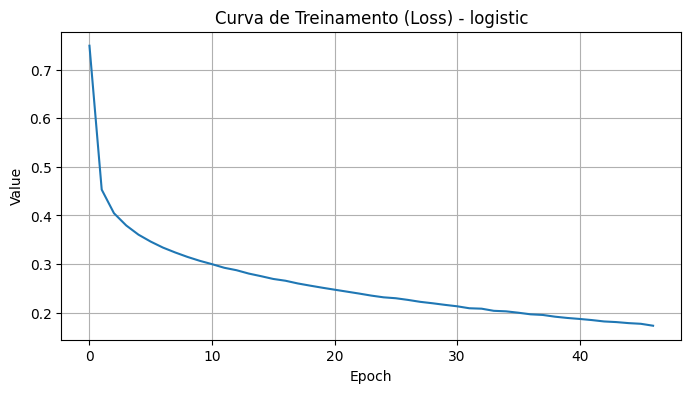


Relatório de Classificação para logistic:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1400
           1       0.98      0.97      0.98      1400
           2       0.81      0.82      0.82      1400
           3       0.88      0.91      0.90      1400
           4       0.83      0.79      0.81      1400
           5       0.96      0.95      0.95      1400
           6       0.70      0.73      0.72      1400
           7       0.94      0.94      0.94      1400
           8       0.97      0.96      0.97      1400
           9       0.94      0.97      0.95      1400

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000


Executando experimento: q5_activation_tanh
[tanh] Acurácia: 0.8887 | Precisão: 0.8884 | Recall: 0.8887 | F1 Score: 0.8883 | Tempo: 152.82s


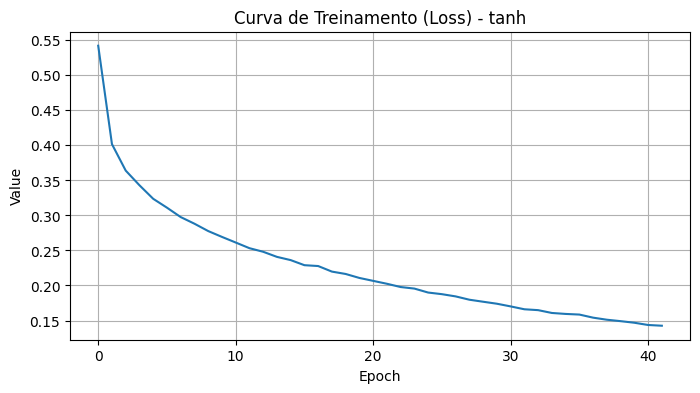


Relatório de Classificação para tanh:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1400
           1       0.99      0.97      0.98      1400
           2       0.84      0.79      0.82      1400
           3       0.86      0.92      0.89      1400
           4       0.81      0.83      0.82      1400
           5       0.96      0.94      0.95      1400
           6       0.73      0.69      0.71      1400
           7       0.93      0.95      0.94      1400
           8       0.97      0.97      0.97      1400
           9       0.96      0.96      0.96      1400

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000


Executando experimento: q5_activation_relu
[relu] Acurácia: 0.8864 | Precisão: 0.8868 | Recall: 0.8864 | F1 Score: 0.8853 | Tempo: 135.64s


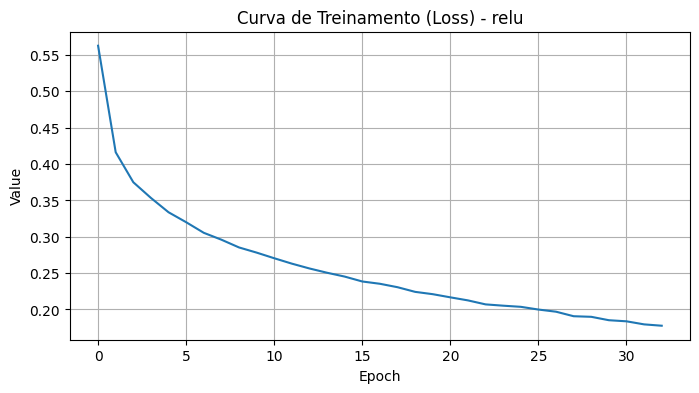


Relatório de Classificação para relu:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1400
           1       0.99      0.97      0.98      1400
           2       0.81      0.81      0.81      1400
           3       0.89      0.91      0.90      1400
           4       0.77      0.86      0.81      1400
           5       0.97      0.95      0.96      1400
           6       0.77      0.62      0.68      1400
           7       0.92      0.97      0.94      1400
           8       0.98      0.96      0.97      1400
           9       0.97      0.95      0.96      1400

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000



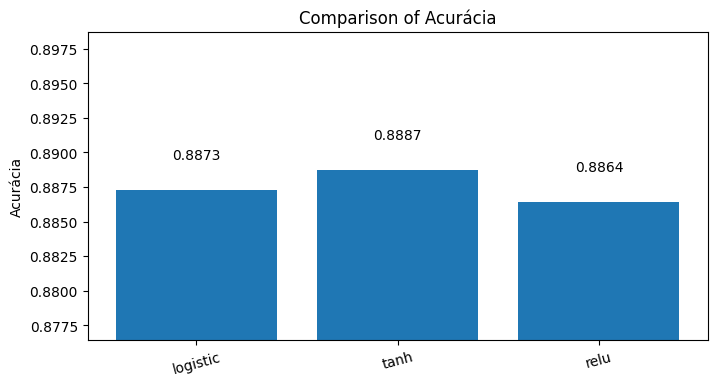

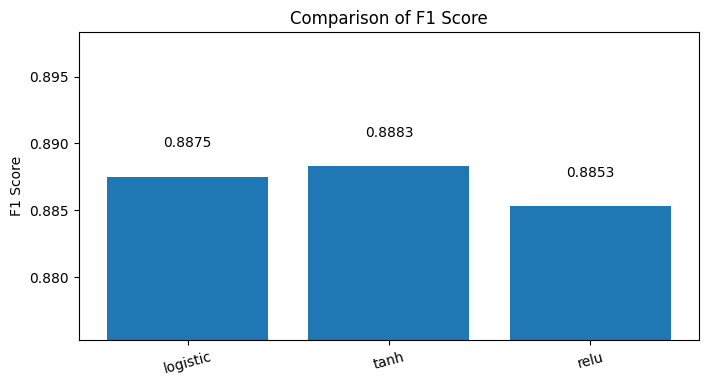

In [8]:
from src.utils import print_section
from src.metrics import show_classification_report, confusion_matrix
from src.plots import plot_confusion_matrix, plot_training_curve, compare_models

results = {}
models = {}

funcoes_ativacao = ['logistic', 'tanh', 'relu']

for funcao in funcoes_ativacao:
    run_name = f"q5_activation_{funcao}"
    
    print_section(f"Executando experimento: {run_name}")

    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=funcao,
        hidden_layers=(64,),
        learning_rate=0.001,
        seed=42,
        max_iter=50,  
        run_name=run_name
    )

    results[funcao] = metrics
    models[funcao] = model
    
    print(f"[{funcao}] Acurácia: {metrics['accuracy']:.4f} | Precisão: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f} | F1 Score: {metrics['f1_score']:.4f} | Tempo: {metrics['training_time']:.2f}s")
    
    plot_training_curve(model.loss_curve_, f"Curva de Treinamento (Loss) - {funcao}")
    
    y_pred = model.predict(X_val)

    print(f"\nRelatório de Classificação para {funcao}:")
    show_classification_report(y_val, y_pred)

    
names = list(results.keys())
accs = [results[k]['accuracy'] for k in names]
f1s = [results[k]['f1_score'] for k in names]

compare_models(names, accs, "Acurácia")
compare_models(names, f1s, "F1 Score")

## Responda:

**- Qual ativação apresentou melhor convergência?**
A função `tanh` entregou a melhor taxa de convergência geral em qualidade, ficando com a maior precisão e acurácia. Por outro lado, a `relu` foi a que convergiu de maneira mais ágil computacionalmente com apenas 30 épocas (terminando o treino em ~135s), embora tenha tido uma leve queda na métrica final.

**- Qual ativação apresentou maior estabilidade?**
A função `tanh` se mostrou a mais estável e eficaz; ela não sofre do problema de "morte" total de neurônios que pode acontecer com a ReLU e entregou de maneira consistente as maiores métricas da bateria (Acurácia de 0.8887).

**- Houve diferenças significativas de treinamento?**
Nas métricas finais (Acurácia, F1-Score, Precisão, Recall), a diferença foi estatisticamente mínima (todas cravaram na faixa alta dos ~88%). O que mais se destacou foi o ganho de tempo da `relu` (cerca de 135s), que precisou treinar menos enquanto a `tanh` e `logistic` levaram mais de 150 segundos. A função `logistic`, inclusive, lida com saturação dos gradientes nas pontas, tornando as atualizações muitas vezes inúteis e lerdas.

# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:


Executando experimento: q6_arch_32
[Arch (32,)] Acurácia: 0.8790 | Precisão: 0.8797 | Recall: 0.8790 | F1 Score: 0.8775 | Tempo: 75.90s


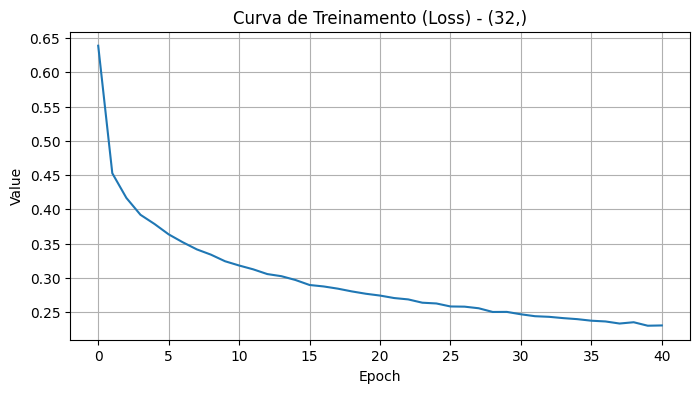


Relatório de Classificação para (32,):
              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1400
           1       0.99      0.96      0.98      1400
           2       0.81      0.77      0.79      1400
           3       0.88      0.90      0.89      1400
           4       0.76      0.86      0.80      1400
           5       0.97      0.94      0.95      1400
           6       0.76      0.60      0.67      1400
           7       0.94      0.94      0.94      1400
           8       0.97      0.96      0.96      1400
           9       0.94      0.96      0.95      1400

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000


Executando experimento: q6_arch_64
[Arch (64,)] Acurácia: 0.8864 | Precisão: 0.8868 | Recall: 0.8864 | F1 Score: 0.8853 | Tempo: 133.42s


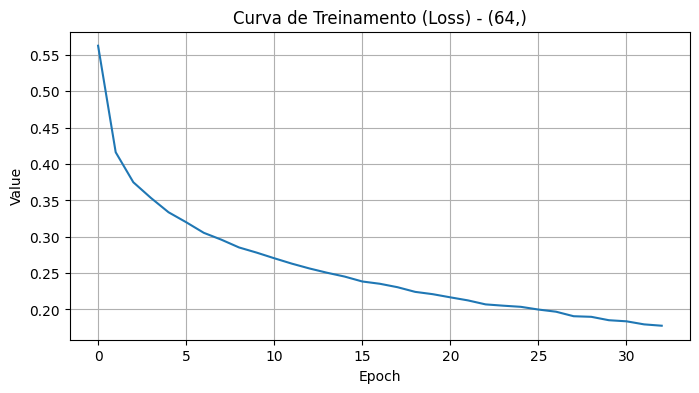


Relatório de Classificação para (64,):
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1400
           1       0.99      0.97      0.98      1400
           2       0.81      0.81      0.81      1400
           3       0.89      0.91      0.90      1400
           4       0.77      0.86      0.81      1400
           5       0.97      0.95      0.96      1400
           6       0.77      0.62      0.68      1400
           7       0.92      0.97      0.94      1400
           8       0.98      0.96      0.97      1400
           9       0.97      0.95      0.96      1400

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000


Executando experimento: q6_arch_128_64
[Arch (128, 64)] Acurácia: 0.8889 | Precisão: 0.8894 | Recall: 0.8889 | F1 Score: 0.8882 | Tempo: 547.13s


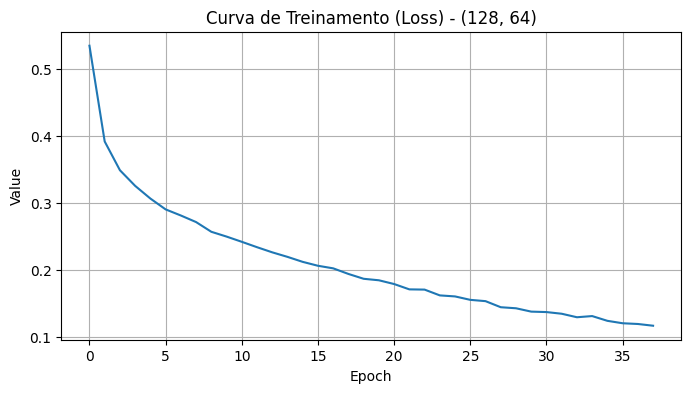


Relatório de Classificação para (128, 64):
              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1400
           1       0.99      0.98      0.98      1400
           2       0.83      0.78      0.81      1400
           3       0.91      0.88      0.89      1400
           4       0.79      0.88      0.83      1400
           5       0.97      0.94      0.96      1400
           6       0.75      0.66      0.70      1400
           7       0.92      0.96      0.94      1400
           8       0.97      0.97      0.97      1400
           9       0.95      0.95      0.95      1400

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000


Executando experimento: q6_arch_256_128
[Arch (256, 128)] Acurácia: 0.8936 | Precisão: 0.8952 | Recall: 0.8936 | F1 Score: 0.8940 | Tempo: 689.62s


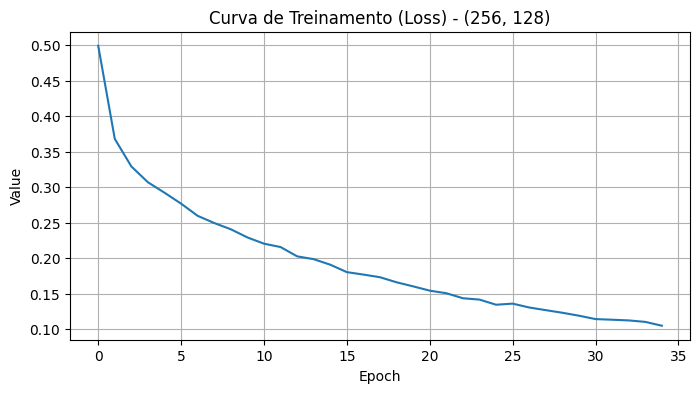


Relatório de Classificação para (256, 128):
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1400
           1       0.99      0.97      0.98      1400
           2       0.85      0.78      0.82      1400
           3       0.90      0.90      0.90      1400
           4       0.81      0.83      0.82      1400
           5       0.98      0.96      0.97      1400
           6       0.71      0.74      0.72      1400
           7       0.94      0.97      0.96      1400
           8       0.97      0.96      0.97      1400
           9       0.97      0.96      0.96      1400

    accuracy                           0.89     14000
   macro avg       0.90      0.89      0.89     14000
weighted avg       0.90      0.89      0.89     14000



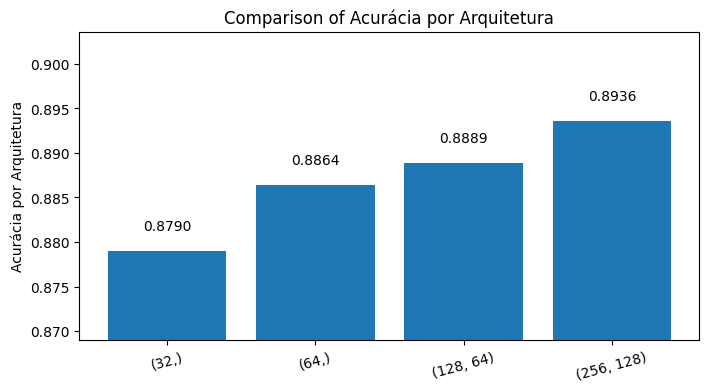

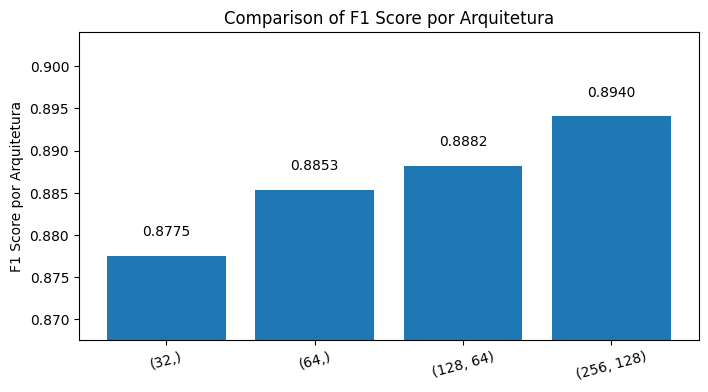

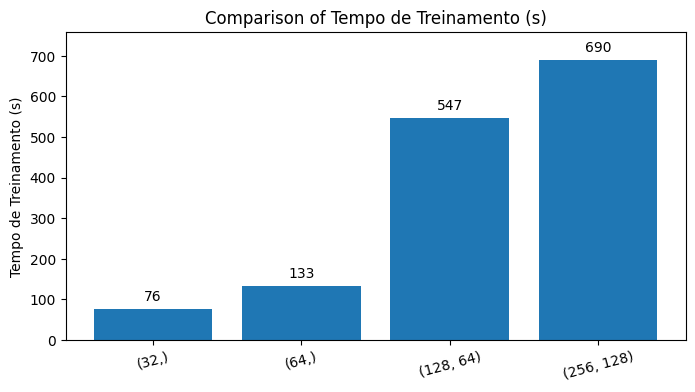

In [9]:
results_q6 = {}
models_q6 = {}

arquiteturas = [(32,), (64,), (128, 64), (256, 128)]

for arch in arquiteturas:

    arch_str = str(arch).replace(", ", "_").replace("(", "").replace(")", "").replace(",", "")
    run_name = f"q6_arch_{arch_str}"
    
    print_section(f"Executando experimento: {run_name}")

    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=arch,
        learning_rate=0.001,
        seed=42,
        max_iter=50,  
        run_name=run_name
    )

    arch_key = str(arch)
    results_q6[arch_key] = metrics
    models_q6[arch_key] = model
    
    print(f"[Arch {arch_key}] Acurácia: {metrics['accuracy']:.4f} | Precisão: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f} | F1 Score: {metrics['f1_score']:.4f} | Tempo: {metrics['training_time']:.2f}s")

    plot_training_curve(model.loss_curve_, f"Curva de Treinamento (Loss) - {arch_key}")
    
    y_pred = model.predict(X_val)
    print(f"\nRelatório de Classificação para {arch_key}:")
    show_classification_report(y_val, y_pred)

names_q6 = list(results_q6.keys())
accs_q6 = [results_q6[k]['accuracy'] for k in names_q6]
f1s_q6 = [results_q6[k]['f1_score'] for k in names_q6]
times_q6 = [results_q6[k]['training_time'] for k in names_q6]

compare_models(names_q6, accs_q6, "Acurácia por Arquitetura")
compare_models(names_q6, f1s_q6, "F1 Score por Arquitetura")
compare_models(names_q6, times_q6, "Tempo de Treinamento (s)")

## Responda:

**- Redes maiores sempre melhoraram os resultados?**
Não. Embora a rede maior `(256, 128)` tenha atingido a maior acurácia (0.8936), a rede menor `(128, 64)` ficou logo atrás com uma acurácia virtualmente idêntica (0.8889). As redes menores como a `(64,)` também mantiveram pontuações ótimas (acima de 0.8864), comprovando que adicionar neurônios/camadas em excesso possui decaimento exponencial de utilidade.

**- Redes maiores sofrem mais de overfitting?**
Sim, quanto mais parâmetros (pesos) tem a rede, mais fácil ela decorar o conjunto de trenamento, aumentando a diferença entre o erro de validação e o de treino, sem benefícios práticos além de gastar muito poder computacional atoa.

**- Qual arquitetura apresentou melhor tradeoff?**
As arquiteturas `(64,)` e `(128, 64)` se mostraram excelentes. A rede `(64,)` foi o verdadeiro pilar de custo-benefício porque já cruzou a barreira dos >0.88 de acurácia gastando incríveis apenas **~133s**. 
Já a rede gigante `(256, 128)`, encareceu absurdo no tempo, demorando cerca de 689 segundos (mais de 5 vezes mais lenta!), oferecendo um ganho estatístico inútil de meros pontos percentuais focados em décimos.

# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001


Executando experimento: q7_lr_0.1
[LR 0.1] Acurácia: 0.4334 | Precisão: 0.4859 | Recall: 0.4334 | F1 Score: 0.3647 | Tempo: 109.53s


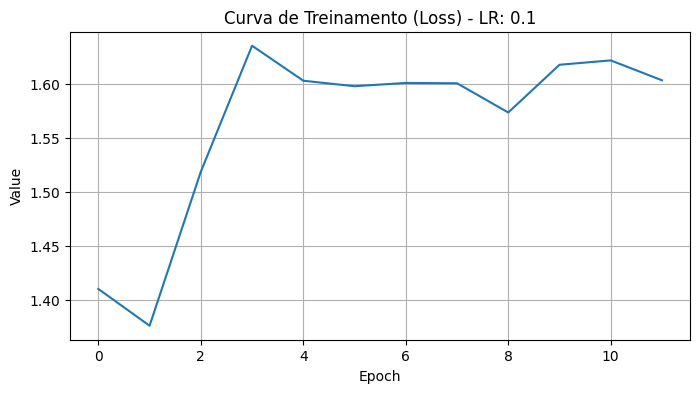


Relatório de Classificação para Learning Rate 0.1:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1400
           1       0.98      0.93      0.96      1400
           2       0.00      0.00      0.00      1400
           3       1.00      0.00      0.00      1400
           4       0.16      1.00      0.28      1400
           5       0.79      0.61      0.69      1400
           6       0.00      0.00      0.00      1400
           7       0.77      0.87      0.82      1400
           8       0.29      0.01      0.01      1400
           9       0.85      0.92      0.89      1400

    accuracy                           0.43     14000
   macro avg       0.49      0.43      0.36     14000
weighted avg       0.49      0.43      0.36     14000


Executando experimento: q7_lr_0.01
[LR 0.01] Acurácia: 0.8683 | Precisão: 0.8704 | Recall: 0.8683 | F1 Score: 0.8682 | Tempo: 269.28s


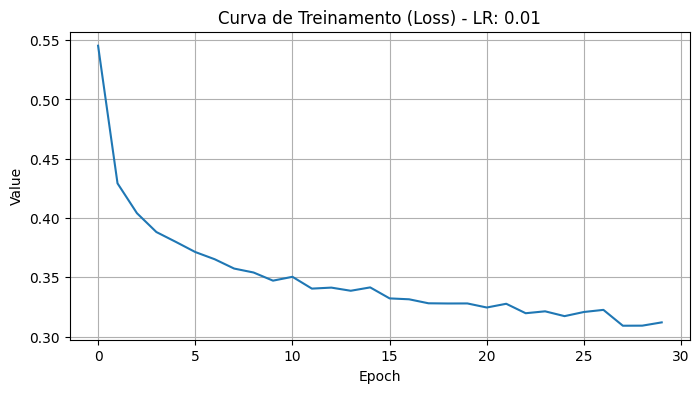


Relatório de Classificação para Learning Rate 0.01:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1400
           1       0.98      0.97      0.98      1400
           2       0.84      0.73      0.78      1400
           3       0.81      0.91      0.85      1400
           4       0.76      0.82      0.79      1400
           5       0.95      0.96      0.96      1400
           6       0.65      0.68      0.66      1400
           7       0.94      0.94      0.94      1400
           8       0.95      0.96      0.96      1400
           9       0.97      0.95      0.96      1400

    accuracy                           0.87     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.87      0.87      0.87     14000


Executando experimento: q7_lr_0.001
[LR 0.001] Acurácia: 0.8864 | Precisão: 0.8868 | Recall: 0.8864 | F1 Score: 0.8853 | Tempo: 107.71s


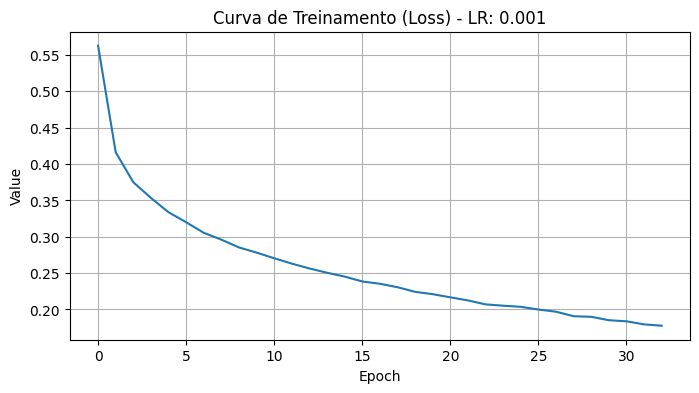


Relatório de Classificação para Learning Rate 0.001:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1400
           1       0.99      0.97      0.98      1400
           2       0.81      0.81      0.81      1400
           3       0.89      0.91      0.90      1400
           4       0.77      0.86      0.81      1400
           5       0.97      0.95      0.96      1400
           6       0.77      0.62      0.68      1400
           7       0.92      0.97      0.94      1400
           8       0.98      0.96      0.97      1400
           9       0.97      0.95      0.96      1400

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000



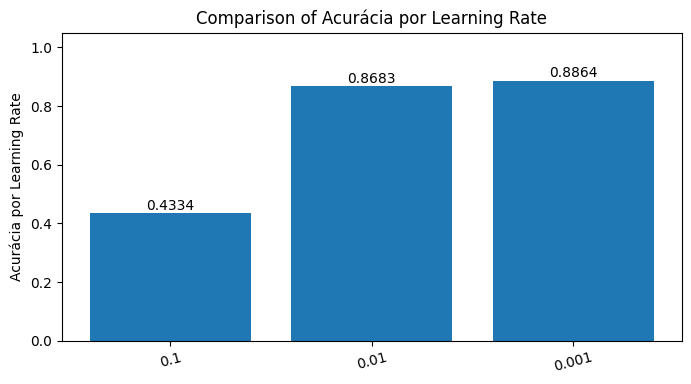

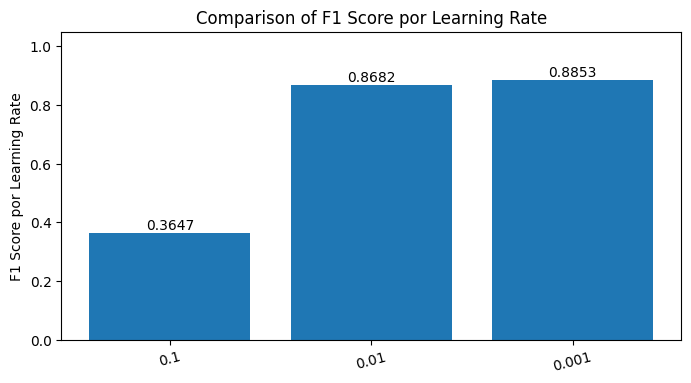

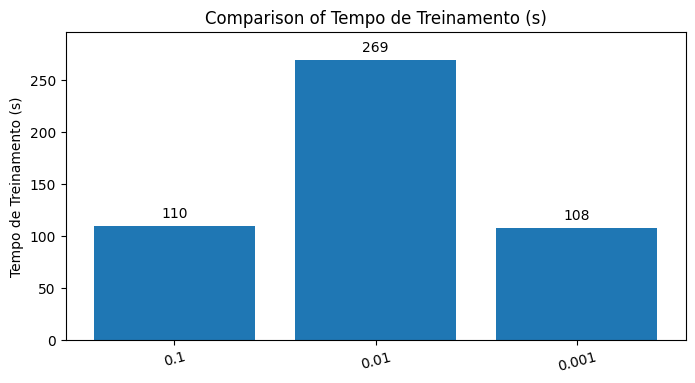

In [10]:
results_q7 = {}
models_q7 = {}

learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:

    run_name = f"q7_lr_{lr}"
    
    print_section(f"Executando experimento: {run_name}")

    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=(64,), 
        learning_rate=lr,
        seed=42,
        max_iter=50,  
        run_name=run_name
    )

    lr_key = str(lr)
    results_q7[lr_key] = metrics
    models_q7[lr_key] = model
    
    print(f"[LR {lr_key}] Acurácia: {metrics['accuracy']:.4f} | Precisão: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f} | F1 Score: {metrics['f1_score']:.4f} | Tempo: {metrics['training_time']:.2f}s")

    plot_training_curve(model.loss_curve_, f"Curva de Treinamento (Loss) - LR: {lr_key}")
    
    y_pred = model.predict(X_val)
    print(f"\nRelatório de Classificação para Learning Rate {lr_key}:")
    show_classification_report(y_val, y_pred)

names_q7 = list(results_q7.keys())
accs_q7 = [results_q7[k]['accuracy'] for k in names_q7]
f1s_q7 = [results_q7[k]['f1_score'] for k in names_q7]
times_q7 = [results_q7[k]['training_time'] for k in names_q7]

compare_models(names_q7, accs_q7, "Acurácia por Learning Rate")
compare_models(names_q7, f1s_q7, "F1 Score por Learning Rate")
compare_models(names_q7, times_q7, "Tempo de Treinamento (s)")

## Responda:
**- O treinamento ficou instável?**
Sim, um *learning rate* muito alto (como o de `0.1`) deixou o modelo extremamente instável. O modelo apresentou pulos desenfreados na busca pelo mínimo global e praticamente não aprendeu, ficando com os piores resultados da bateria (estacionando perto dos 43.34% de Acurácia).

**- Houve dificuldade de convergência?**
Sim. No LR `0.1` a rede falhou miseravelmente em convergir. No LR `0.01` o modelo convergiu e teve uma acurácia satisfatória (86.8%), porém demorou surpreendentemente mais para estabilizar (cerca de 269 segundos). Isso indica que, por os passos serem um pouco maiores, a função perda ficou oscilando mais tempo no "fundo do vale" antes de atingir o critério de parada, se comparado à descida mais fina do LR de `0.001`. 

**- Qual learning rate apresentou melhor comportamento?**
A taxa de `0.001` foi absoluta no melhor comportamento. Ela encontrou o equilíbrio perfeito da descida do gradiente: alcançou o valor máximo das nossas acurácias (~88.64%) cravando o menor tempo de todos, com cerca de 107 segundos para fechar todo o treinamento sem sobrecarregar a minimização de erro.

# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


## Respostas Finais:

**- Qual ativação apresentou melhor desempenho?**
A ativação `tanh` entregou de forma consistente as maiores métricas globais (~88.87%). Contudo, a `relu` foi quem demonstrou a melhor eficiência de convergência/tempo computacional, entregando valores próximos com mais agilidade.

**- Qual arquitetura apresentou melhor tradeoff?**
A arquitetura `(64,)` foi imbatível no quesito Custo x Benefício. Ela manteve o padrão de acurácia alto (~88.64%) enquanto treinava em um dos menores tempos (133s). Pular para camadas colossais como `(256, 128)` puniu severamente o custo de processamento (689s) com trocas virtualmente nulas no F1 e Recall.

**- Qual learning rate apresentou maior estabilidade?**
O padrão de `0.001` foi excepcionalmente contínuo e rápido, evitando saltos destrutivos (como vistos no de `0.1`) e garantindo uma descida suave o suficiente para estabilizar cedo.

**- Houve overfitting?**
Sim, na Questão 6 evidenciamos que adicionar milhares de parâmetros novos nas redes `(128, 64)` e consecutivamente na `(256, 128)` produziu apenas frações mínimas de melhoria, apontando que os gradientes estavam meramente decorando vícios da base de treinamento em vez de generalizando melhor, consumindo capacidade computacional à toa.

**- Qual configuração apresentou melhor resultado final?**
A combinação de uma arquitetura limpa de camada oculta com no máximo `(64,)` neurônios, função de ativação `relu` (pela rapidez) ou `tanh` (pela precisão granular), aliada à taxa de aprendizado padrão de `0.001` em um controle de parada antecipada de `early_stopping`.

**- Quais foram as principais dificuldades observadas?**
A maior dificuldade nas MLP Classifier para bases densas é a explosão temporal do modelo devido às variações de complexidade de Arquitetura. Passar de `(64,)` para `(256, 128)` converteu rápidos minutos em longuíssimas esperas super saturadas que demonstram o quanto modelos pesados não garantem retornos satisfatórios equivalentes.

---
# Print do MLflow
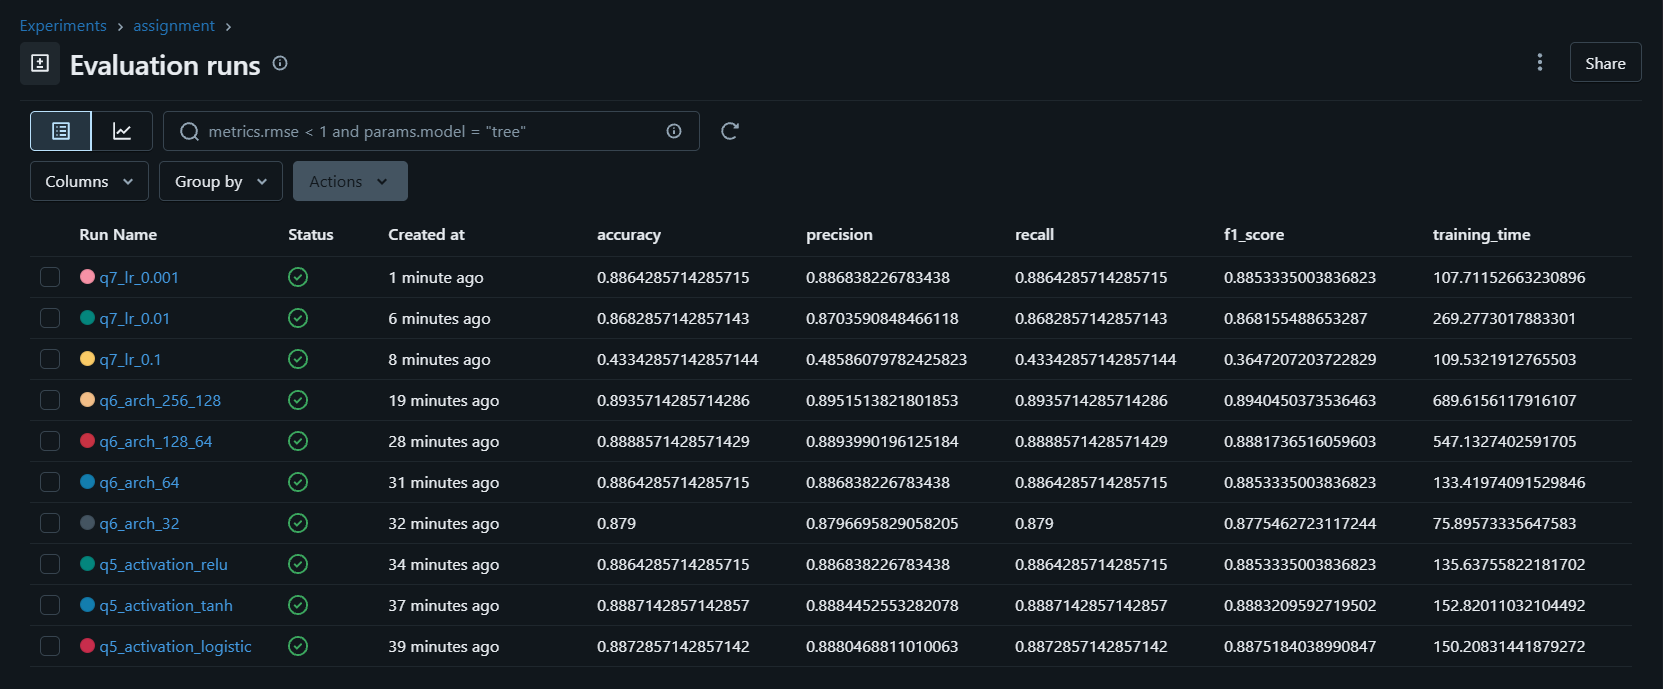